# Retail Sales Data - Exploratory Data Analysis

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA)
on retail sales data to uncover sales patterns, customer behaviour,
product trends, and actionable business insights.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns    

%matplotlib inline

In [5]:
df = pd.read_csv("retail_sales.csv")

df.head()   

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [6]:
df.tail()


,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


## 1. Initial Data Inspection

We first inspect the dataset to understand its structure, number of
records, data types, and missing values.

In [8]:
print("Number of rows and columns:", df.shape)

Number of rows and columns: (1000, 9)


In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [10]:
df.isnull().sum()

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
dtype: int64

In [11]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [14]:

df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

## 2. Descriptive Statistics

Descriptive statistics help us understand the central tendency and
variability of the numerical variables in the retail sales dataset.

We calculate the mean, median, mode, and standard deviation for
the numerical columns.


In [16]:
# Select numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns

# Mean
mean_values = df[numeric_cols].mean()

# Median
median_values = df[numeric_cols].median()

# Mode
mode_values = df[numeric_cols].mode().iloc[0]

# Standard deviation
std_values = df[numeric_cols].std()

# Combine results into one table
statistics = pd.DataFrame({
    "Mean": mean_values,
    "Median": median_values,
    "Mode": mode_values,
    "Standard Deviation": std_values
})

statistics

Transaction ID    500.500
Age                41.392
Quantity            2.514
Price per Unit    179.890
Total Amount      456.000
dtype: float64


,Mean,Median,Mode,Standard Deviation
Transaction ID,500.500,500.5,1.0,288.819436
Age,41.392,42.0,43.0,13.681430
Quantity,2.514,3.0,4.0,1.132734
Price per Unit,179.890,50.0,50.0,189.681356
Total Amount,456.000,135.0,50.0,559.997632


In [17]:
df.columns 

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [20]:
df["Date"] = pd.to_datetime(df["Date"]).astype("datetime64[ns]")

In [22]:
df["Date"].dtype

dtype('<M8[ns]')

## 3. Monthly Sales Trend

Monthly sales are analysed to identify changes in revenue over time
and determine whether there are noticeable seasonal patterns.

In [23]:
monthly_sales = df.groupby(
    df["Date"].dt.to_period("M")
)["Total Amount"].sum()

monthly_sales

Date
2023-01    35450
2023-02    44060
2023-03    28990
2023-04    33870
2023-05    53150
2023-06    36715
2023-07    35465
2023-08    36960
2023-09    23620
2023-10    46580
2023-11    34920
2023-12    44690
2024-01     1530
Freq: M, Name: Total Amount, dtype: int64

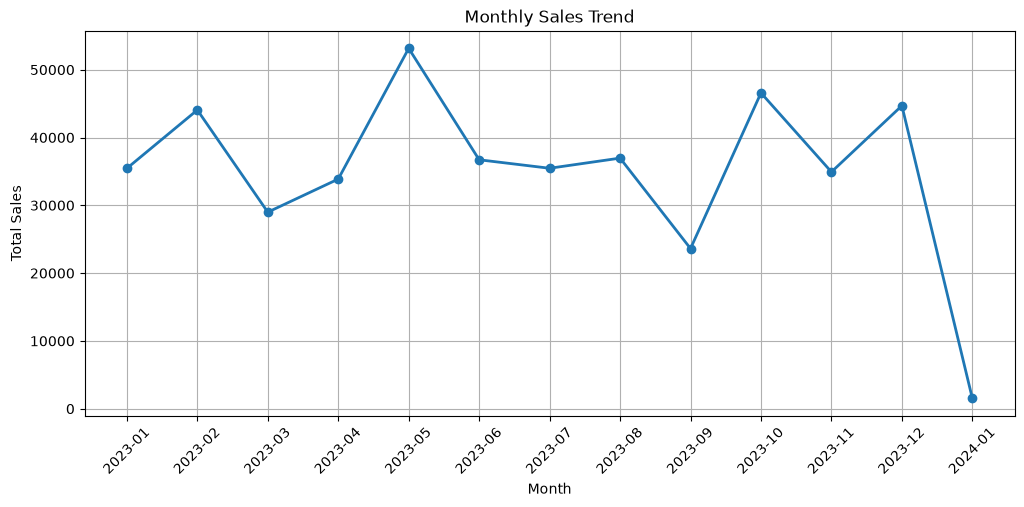

In [24]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [25]:
quarterly_sales = df.groupby(
    df["Date"].dt.to_period("Q")
)["Total Amount"].sum()

quarterly_sales

Date
2023Q1    108500
2023Q2    123735
2023Q3     96045
2023Q4    126190
2024Q1      1530
Freq: Q-DEC, Name: Total Amount, dtype: int64

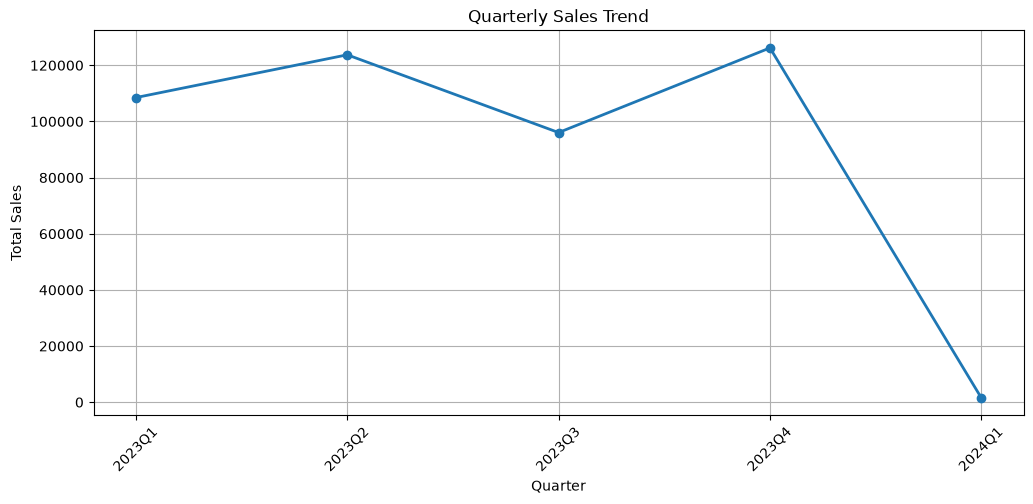

In [26]:
plt.figure(figsize=(12, 5))

plt.plot(
    quarterly_sales.index.astype(str),
    quarterly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Quarterly Sales Trend")
plt.xlabel("Quarter")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

## 4. Customer Demographics Analysis

Customer demographics are analysed using age groups and gender
distribution to understand the characteristics of the customer base.

In [27]:
bins = [0, 25, 35, 45, 55, 100]
labels = ["18-25", "26-35", "36-45", "46-55", "56+"]

df["Age Group"] = pd.cut(
    df["Age"],
    bins=bins,
    labels=labels
)

df["Age Group"].value_counts().sort_index()

Age Group
18-25    169
26-35    205
36-45    202
46-55    229
56+      195
Name: count, dtype: int64

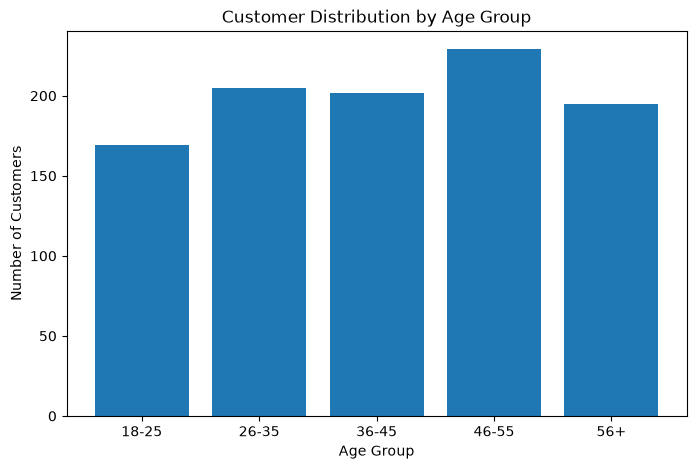

In [28]:
age_counts = df["Age Group"].value_counts().sort_index()

plt.figure(figsize=(8, 5))

plt.bar(age_counts.index, age_counts.values)

plt.title("Customer Distribution by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Customers")

plt.show()

### Observation

The age group 46-55 has the highest number of customers,
while 18-25 has the lowest representation. This indicates that
the business should focus its marketing efforts on the most
represented customer age group while exploring opportunities
to attract customers from underrepresented groups.

In [29]:
gender_counts = df["Gender"].value_counts()

gender_counts

Gender
Female    510
Male      490
Name: count, dtype: int64

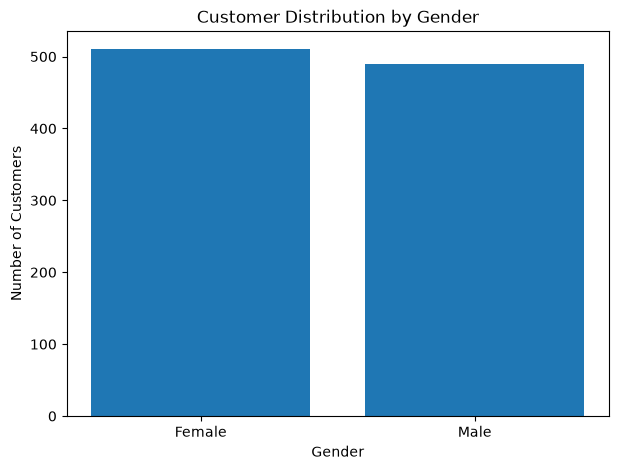

In [30]:
plt.figure(figsize=(7, 5))

plt.bar(gender_counts.index, gender_counts.values)

plt.title("Customer Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")

plt.show()

In [32]:
gender_percentage = df["Gender"].value_counts(normalize=True) * 100

gender_percentage = gender_percentage.round(2).astype(str) + "%"

gender_percentage

Gender
Female    51.0%
Male      49.0%
Name: proportion, dtype: str

# Business Recommendations

### 1. Focus marketing on the dominant age group
The 26–35 age group represents the largest customer segment.
The company should create targeted digital marketing campaigns,
offers, and product recommendations specifically for this age group
to improve customer engagement and sales.

### 2. Develop gender-focused marketing strategies
Female customers represent 51.2% of the customer base.
The company could introduce targeted promotions and personalized
product recommendations for this customer segment while continuing
to maintain products and campaigns for male customers.

### 3. Focus inventory and promotions on high-performing categories
The analysis of revenue by product category can identify the
categories generating the highest sales. The company should
prioritize inventory availability and promotional campaigns for
these high-performing categories to maximize revenue.